 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


Load Dataset

In [4]:
DATA_PATH = "../data/raw/Delinquency_prediction_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


Initial Inspection

In [5]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 500
Columns : 19


Dataset Dimensions

In [6]:
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [7]:
df.tail()

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
495,CUST0496,71,48307.0,688.0,0.486522,2,0,12707.0,0.373033,retired,9,Business,Phoenix,On-time,On-time,Missed,On-time,On-time,Late
496,CUST0497,60,86180.0,836.0,0.608174,2,1,45595.0,0.291943,Unemployed,18,Student,Houston,On-time,On-time,Late,Late,Late,Missed
497,CUST0498,54,152326.0,847.0,0.676950,0,0,44449.0,0.104839,Employed,16,Student,Phoenix,On-time,Late,Late,On-time,Late,Missed
498,CUST0499,50,105852.0,343.0,0.700643,2,1,11155.0,0.236477,Employed,11,Student,Phoenix,Late,On-time,Late,Missed,On-time,Missed
499,CUST0500,25,40945.0,442.0,0.911370,1,0,36968.0,0.370422,Self-employed,0,Business,Houston,Missed,Late,Late,On-time,Late,On-time


In [8]:
df.sample(5, random_state=42)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
361,CUST0362,58,180421.0,679.0,0.971116,2,0,53553.0,0.291088,employed,15,Gold,Phoenix,Late,Missed,Late,On-time,On-time,Late
73,CUST0074,21,36447.0,448.0,0.878607,3,0,13355.0,0.187290,Self-employed,11,Business,Houston,On-time,On-time,Missed,Late,On-time,Missed
374,CUST0375,34,101900.0,648.0,0.787708,1,1,48942.0,0.314334,Unemployed,14,Standard,Houston,Missed,Missed,Missed,Missed,On-time,Missed
155,CUST0156,22,119185.0,711.0,0.943684,0,0,44454.0,0.205295,employed,11,Student,Phoenix,Late,Missed,On-time,Late,Missed,Missed
104,CUST0105,42,178165.0,383.0,0.425235,2,0,NaN,0.176706,Self-employed,15,Gold,New York,Missed,On-time,Missed,On-time,On-time,Late


Summary Statistics:

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,500.0,46.266000,16.187629,18.00,33.000000,46.500000,59.250000,74.000000
Income,461.0,108379.893709,53662.723741,15404.00,62295.000000,107658.000000,155734.000000,199943.000000
Credit_Score,498.0,577.716867,168.881211,301.00,418.250000,586.000000,727.250000,847.000000
Credit_Utilization,500.0,0.491446,0.197103,0.05,0.356486,0.485636,0.634440,1.025843
Missed_Payments,500.0,2.968000,1.946935,0.00,1.000000,3.000000,5.000000,6.000000
Delinquent_Account,500.0,0.160000,0.366973,0.00,0.000000,0.000000,0.000000,1.000000
Loan_Balance,471.0,48654.428875,29395.537273,612.00,23716.500000,45776.000000,75546.500000,99620.000000
Debt_to_Income_Ratio,500.0,0.298862,0.094521,0.10,0.233639,0.301634,0.362737,0.552956
Account_Tenure,500.0,9.740000,5.923054,0.00,5.000000,10.000000,15.000000,19.000000


In [10]:
df.describe(include="object").T

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18040\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Customer_ID,500,500,CUST0001,1
Employment_Status,500,6,Unemployed,93
Credit_Card_Type,500,5,Gold,118
Location,500,5,Los Angeles,107
Month_1,500,3,On-time,177
Month_2,500,3,Late,173
Month_3,500,3,Late,169
Month_4,500,3,Late,181
Month_5,500,3,Missed,187
Month_6,500,3,Late,172


Check Missing Values:

In [11]:
missing = (
    df.isnull()
      .sum()
      .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(df)
) * 100

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Income,39,7.8
Loan_Balance,29,5.8
Credit_Score,2,0.4
Age,0,0.0
Customer_ID,0,0.0
Missed_Payments,0,0.0
Credit_Utilization,0,0.0
Delinquent_Account,0,0.0
Debt_to_Income_Ratio,0,0.0
Employment_Status,0,0.0


Visualize Missing Values

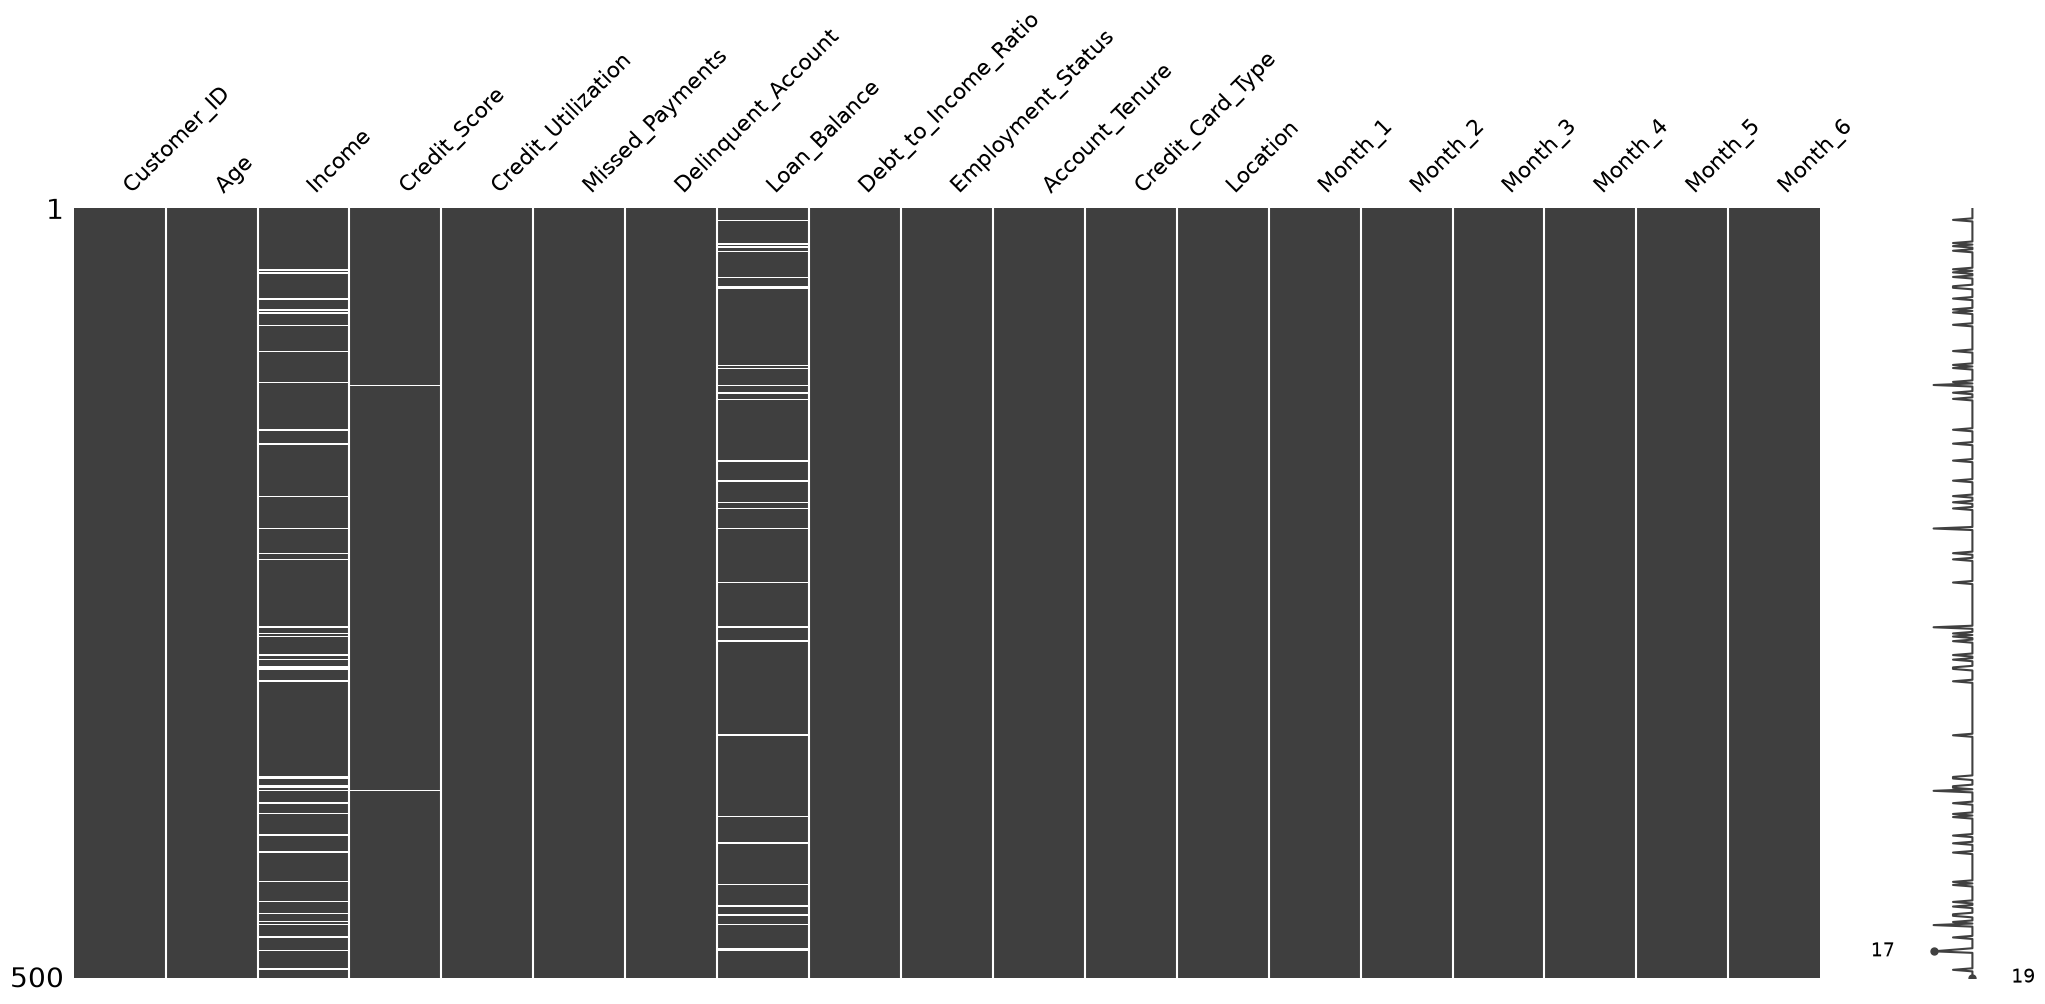

In [12]:
msno.matrix(df)
plt.show()

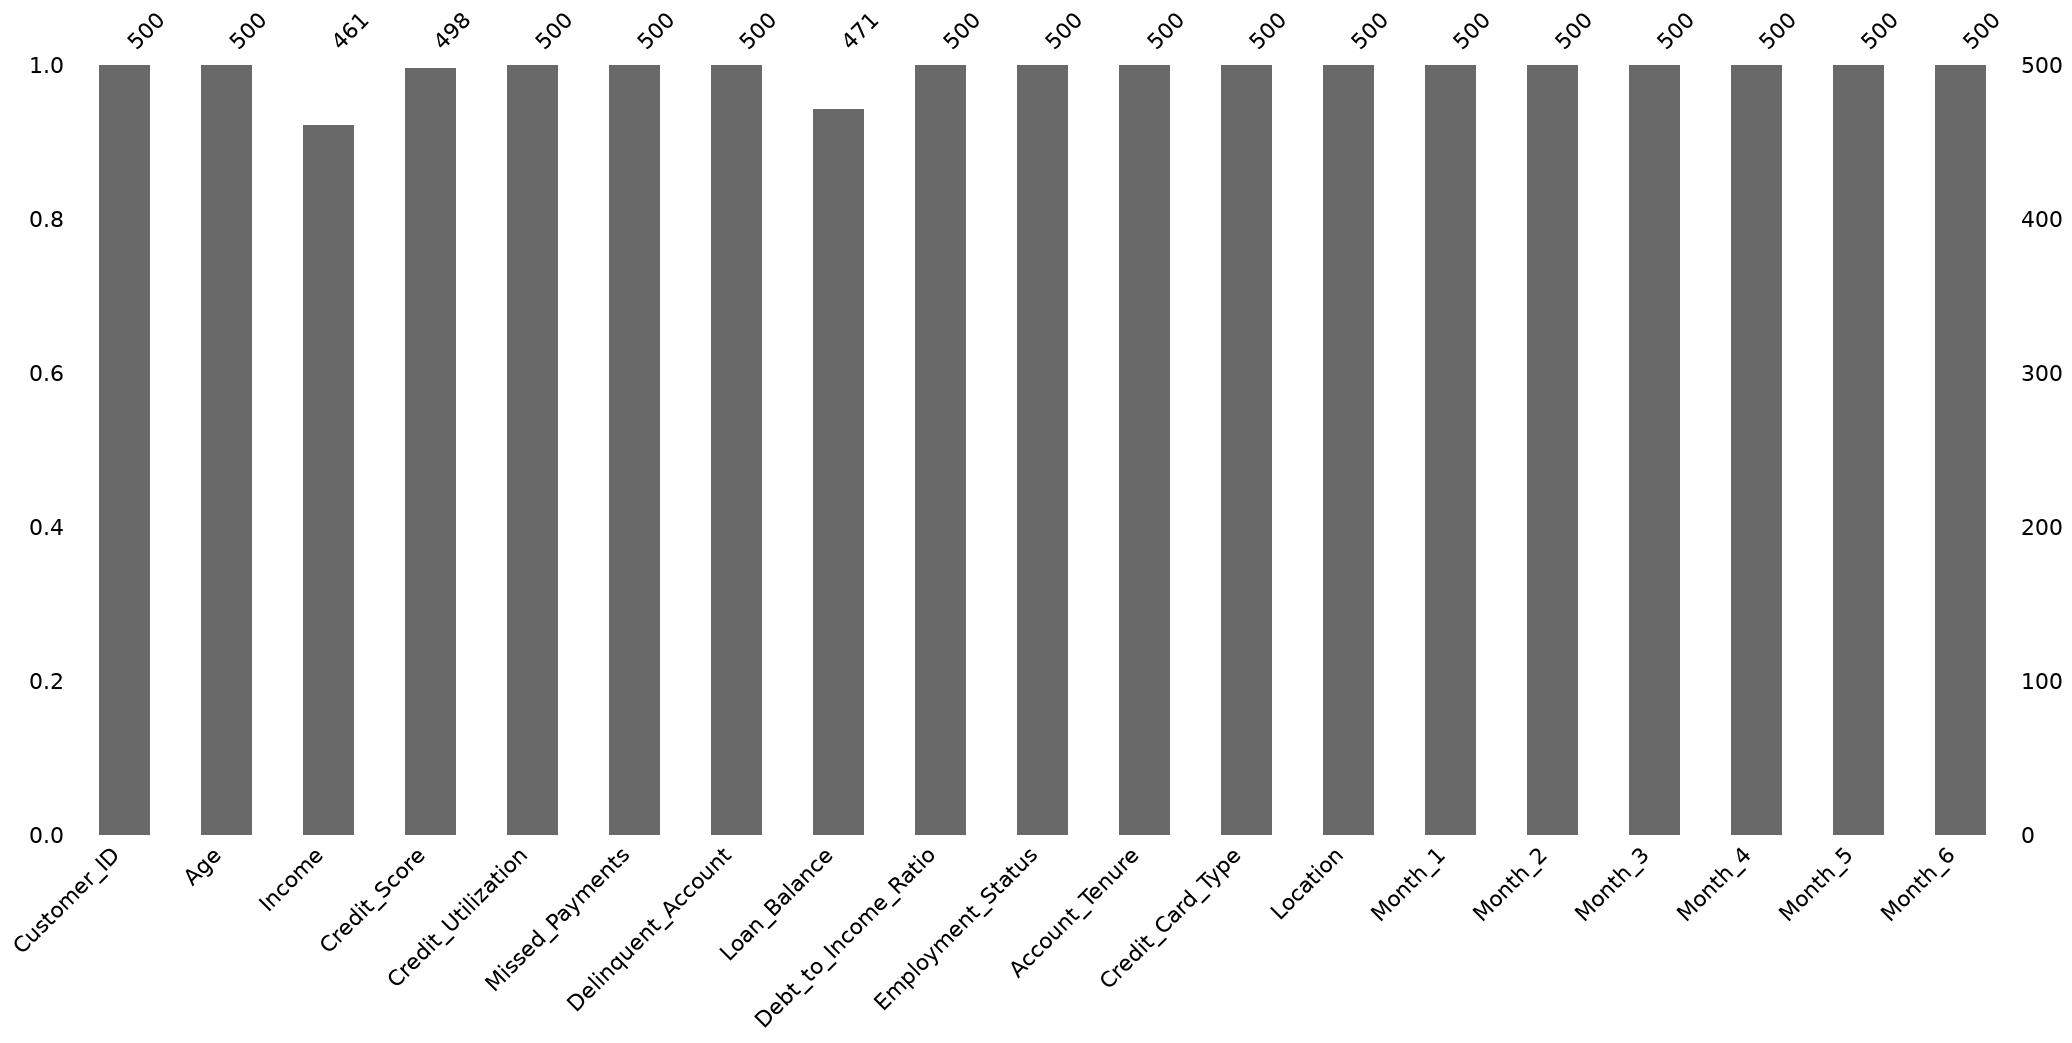

In [13]:
msno.bar(df)
plt.show()

Check for Duplicates

In [14]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0
